In [2]:
# importing the basic libraries
import numpy as np # to handle numeric values
import pandas as pd # to handle data related task
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv(r"C:\Users\Greesha Vaishnavi\Desktop\Housing_Prices\Housing.csv") # fetching file folder and reading the file

"Shape:", 
df.shape
df.head() 

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
X = df.drop(columns = ['price']) # basically the split is like X=> which has all the features or one feature if it has multiple features it will be a feature matrix(expect target variable)
y = df['price'] # y is our target variable

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

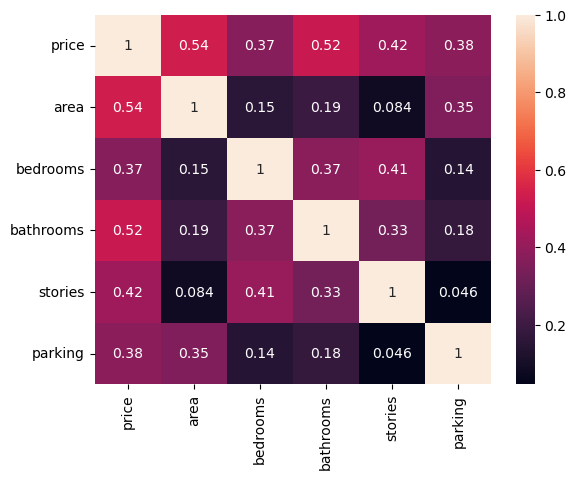

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

<Axes: xlabel='price'>

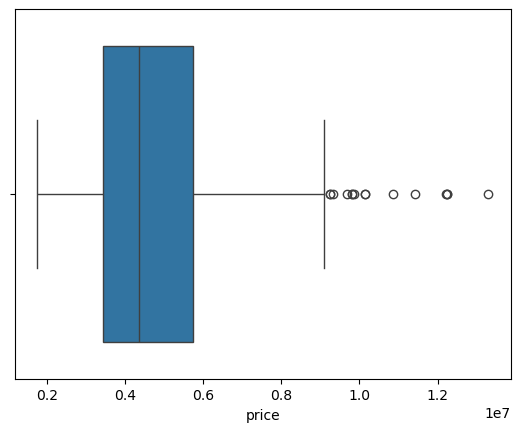

In [10]:
sns.boxplot(x=df["price"])

In [11]:
columns = [                                       
    'mainroad',
    'guestroom',               # endcoding process : the process of converting information or data from one format into another
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea']
for col in columns:
    df[col]=df[col].map({
        'yes':1 ,
        'no':1
    })

In [12]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True) 

In [13]:
X = df.drop(columns = ['price'])
y = df['price']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape) 

(436, 13)
(109, 13)
(436,)
(109,)


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

In [23]:
print(mse)                    # checking accuracy in target variable price 
print(rmse)
print(mae)
print(r2)

2229169358205.058
1493040.306959279
1112059.1858898462
0.5589794483892097


In [24]:
for feature, weight in zip(X.columns, model.coef_):
    print(f"{feature}: {weight}")

area: 300.8286350740693
bedrooms: 144537.7138660088
bathrooms: 1154900.5149259309
stories: 464070.18166300585
mainroad: -3.4924596548080444e-10
guestroom: 1.1641532182693481e-10
basement: 0.0
hotwaterheating: 0.0
airconditioning: 0.0
parking: 294519.57224558044
prefarea: 0.0
furnishingstatus_semi-furnished: -280890.1838861444
furnishingstatus_unfurnished: -686630.2666045938
